# Time.CSV 数据分析

这个分析聚焦于运动规划算法的性能对比，包括不同方法的时间消耗统计。

## 1. 导入所需库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 配置可视化
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. 加载CSV数据

In [2]:
csv_data = """seed,ws,origin_time_s,greedy_totg_time_s,trapezoid_time_s,trapezoid_sol_totg_time_s,totg_time_s,trapezoid_sol_true_plan_time_s
10,3,7.436681705,3.90806350442,3.74644574189,3.7464457421,3.7464457421,5.036366657
11,3,8.545892692,5.67929617955,5.43624612845,5.45998134472,5.45998134472,7.292264833
12,3,8.055932197,6.07374762923,5.99469240127,6.07528416325,6.02744964354,8.076901445
13,3,7.536715773,4.56657339959,4.45507547388,4.45507547406,4.45507547406,5.222567425
14,3,6.943481093,5.25936858462,4.71764770592,4.7770710007,4.74291111689,6.506402291
15,3,9.462569943,5.1983452502,4.88955796035,4.96128123013,4.95431920169,6.470545969
16,3,9.916985493,5.43567338753,5.29961077612,5.31179792239,5.31090289265,7.276732351
17,3,8.103685457,4.30942050208,4.3094205019,4.30942050208,4.30942050208,5.844155139
18,3,7.009391978,6.08597326884,4.78153143386,4.84216461654,4.82525939694,6.373226758
19,3,8.051871173,5.03549340575,4.90140358995,4.90140358995,4.90140358995,6.521346911
20,3,7.025767233,4.12113578688,4.1211357867,4.12113578688,4.12113578688,5.874691485
21,3,6.905752859,4.82727198285,4.6007347625,4.64844018332,4.64331257359,6.459373374
22,3,7.74630257,5.42794464537,5.22982997962,5.23831205045,5.23555056246,6.21185615
23,3,8.969565159,5.02347724156,4.9699448543,4.98775907721,4.98775907721,6.634000137
24,3,9.652550047,4.88925246964,4.66386048312,4.6761925248,4.6761925248,6.371397705
25,3,9.234255834,5.14634640728,5.08001848139,5.15305135686,5.14595962986,6.774286094
26,3,8.153439173,5.8720866921,5.63661454367,5.69380696183,5.66575686695,7.107605757
27,3,7.814708422,4.48702573525,4.45866622819,4.50361950488,4.48702573525,6.194556387
28,3,8.201331649,6.11759114987,5.12073589323,5.18897832439,5.17722342018,6.480083766
29,3,9.728342931,4.8931939967,4.86322333667,4.86921857051,4.86326681905,6.528879618
30,3,8.416920015,4.803754031,4.6302983883,4.73594504301,4.67911988578,6.494689208
31,3,8.47510713,4.24383244926,4.15602184873,4.16831212207,4.16831212207,5.848217619
32,3,7.593543772,4.10111900189,4.03699383979,4.06009068426,4.05019853253,5.68739492
33,3,10.016113048,4.73764251526,4.71483652604,4.73764251526,4.73764251526,6.475913594
34,3,9.484126895,5.03785110655,4.96958339494,5.0504145164,5.03785110655,6.400440394
35,3,7.728365549,3.89583737399,3.8958373739,3.89583737399,3.89583737399,4.956646103
36,3,7.974245483,5.20142092629,4.76142463926,4.78212241399,4.78212241399,6.546090055
37,3,9.230462636,4.96686720434,4.86879945879,4.96916649302,4.96686720434,6.533387366
38,3,9.428973554,6.1850331282,5.685539645,5.68993419719,5.68993419719,7.714185629
39,3,8.490554867,4.62582306455,4.60297171876,4.66861546883,4.62582306455,5.799778822"""

df = pd.read_csv(StringIO(csv_data))
print("数据加载成功！")
print(f"数据形状: {df.shape}")
print(f"行数: {len(df)}, 列数: {len(df.columns)}")

数据加载成功！
数据形状: (30, 8)
行数: 30, 列数: 8


## 3. 数据检查

In [3]:
# 显示前几行
print("前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)
print("\n缺失值:")
print(df.isnull().sum())
print("\n基本信息:")
print(df.info())

前5行数据:
   seed  ws  origin_time_s  greedy_totg_time_s  trapezoid_time_s  \
0    10   3       7.436682            3.908064          3.746446   
1    11   3       8.545893            5.679296          5.436246   
2    12   3       8.055932            6.073748          5.994692   
3    13   3       7.536716            4.566573          4.455075   
4    14   3       6.943481            5.259369          4.717648   

   trapezoid_sol_totg_time_s  totg_time_s  trapezoid_sol_true_plan_time_s  
0                   3.746446     3.746446                        5.036367  
1                   5.459981     5.459981                        7.292265  
2                   6.075284     6.027450                        8.076901  
3                   4.455075     4.455075                        5.222567  
4                   4.777071     4.742911                        6.506402  

数据类型:
seed                                int64
ws                                  int64
origin_time_s                     flo

## 4. 汇总统计

In [4]:
# 时间列
time_columns = ['origin_time_s', 'greedy_totg_time_s', 'trapezoid_time_s', 
                'trapezoid_sol_totg_time_s', 'totg_time_s', 'trapezoid_sol_true_plan_time_s']

# 计算统计量
stats_summary = df[time_columns].describe().T
stats_summary['cv'] = stats_summary['std'] / stats_summary['mean']  # 变异系数

print("=" * 80)
print("各时间列的统计摘要 (单位: 秒)")
print("=" * 80)
print(stats_summary.round(4))

# 计算更详细的统计
print("\n" + "=" * 80)
print("详细统计指标")
print("=" * 80)
for col in time_columns:
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"\n{col}:")
    print(f"  均值:     {mean:.6f} s")
    print(f"  中位数:   {median:.6f} s")
    print(f"  标准差:   {std:.6f} s")
    print(f"  范围:     [{min_val:.6f}, {max_val:.6f}] s")

各时间列的统计摘要 (单位: 秒)
                                count    mean     std     min     25%     50%  \
origin_time_s                    30.0  8.3778  0.9408  6.9058  7.7328  8.1774   
greedy_totg_time_s               30.0  5.0052  0.6577  3.8958  4.5814  4.9952   
trapezoid_time_s                 30.0  4.7866  0.5257  3.7464  4.4942  4.7715   
trapezoid_sol_totg_time_s        30.0  4.8226  0.5377  3.7464  4.5398  4.8121   
totg_time_s                      30.0  4.8123  0.5334  3.7464  4.5217  4.8037   
trapezoid_sol_true_plan_time_s   30.0  6.3905  0.6966  4.9566  5.9547  6.4732   

                                   75%      max      cv  
origin_time_s                   9.2333  10.0161  0.1123  
greedy_totg_time_s              5.3858   6.1850  0.1314  
trapezoid_time_s                5.0525   5.9947  0.1098  
trapezoid_sol_totg_time_s       5.1274   6.0753  0.1115  
totg_time_s                     5.1189   6.0274  0.1108  
trapezoid_sol_true_plan_time_s  6.5429   8.0769  0.1090  

详细统计指标


## 5. 时间列对比和性能分析

In [5]:
# 计算相对于origin_time_s的加速比
df['greedy_speedup'] = df['origin_time_s'] / df['greedy_totg_time_s']
df['trapezoid_speedup'] = df['origin_time_s'] / df['trapezoid_time_s']
df['trapezoid_sol_totg_speedup'] = df['origin_time_s'] / df['trapezoid_sol_totg_time_s']
df['totg_speedup'] = df['origin_time_s'] / df['totg_time_s']
df['trapezoid_sol_true_speedup'] = df['origin_time_s'] / df['trapezoid_sol_true_plan_time_s']

print("=" * 80)
print("性能加速比 (相对于origin_time_s)")
print("=" * 80)
speedup_cols = ['greedy_speedup', 'trapezoid_speedup', 'trapezoid_sol_totg_speedup', 
                'totg_speedup', 'trapezoid_sol_true_speedup']
speedup_stats = df[speedup_cols].describe().T
print(speedup_stats.round(4))

# 算法对比 - 时间贡献
print("\n" + "=" * 80)
print("算法时间贡献对比")
print("=" * 80)
algorithm_comparison = pd.DataFrame({
    'Origin (基准)': df['origin_time_s'],
    'Greedy TOTG': df['greedy_totg_time_s'],
    'Trapezoid': df['trapezoid_time_s'],
    'Trapezoid-TOTG': df['trapezoid_sol_totg_time_s'],
    'TOTG': df['totg_time_s'],
    'Trapezoid-Plan': df['trapezoid_sol_true_plan_time_s']
})

print("\n平均值对比 (秒):")
print(algorithm_comparison.mean().round(6))

print("\n最小-最大值范围:")
for col in algorithm_comparison.columns:
    min_val = algorithm_comparison[col].min()
    max_val = algorithm_comparison[col].max()
    print(f"{col:20s}: [{min_val:.6f}, {max_val:.6f}]")

# 计算时间节省
print("\n" + "=" * 80)
print("相对于Origin时间的节省情况")
print("=" * 80)
df['greedy_save'] = (df['origin_time_s'] - df['greedy_totg_time_s']) / df['origin_time_s'] * 100
df['trapezoid_save'] = (df['origin_time_s'] - df['trapezoid_time_s']) / df['origin_time_s'] * 100
df['totg_save'] = (df['origin_time_s'] - df['totg_time_s']) / df['origin_time_s'] * 100

save_cols = ['greedy_save', 'trapezoid_save', 'totg_save']
print("\n时间节省比例 (%):")
print(df[save_cols].describe().T[['mean', 'std', 'min', 'max']].round(2))

性能加速比 (相对于origin_time_s)
                            count    mean     std     min     25%     50%  \
greedy_speedup               30.0  1.6963  0.2484  1.1517  1.5097  1.7688   
trapezoid_speedup            30.0  1.7623  0.2100  1.3438  1.6119  1.8113   
trapezoid_sol_totg_speedup   30.0  1.7498  0.2109  1.3260  1.5961  1.7846   
totg_speedup                 30.0  1.7532  0.2095  1.3365  1.5988  1.7964   
trapezoid_sol_true_speedup   30.0  1.3198  0.1557  0.9974  1.2192  1.3436   

                               75%     max  
greedy_speedup              1.8749  2.1142  
trapezoid_speedup           1.9053  2.1244  
trapezoid_sol_totg_speedup  1.8798  2.1142  
totg_speedup                1.8820  2.1142  
trapezoid_sol_true_speedup  1.4591  1.5592  

算法时间贡献对比

平均值对比 (秒):
Origin (基准)       8.377788
Greedy TOTG       5.005215
Trapezoid         4.786623
Trapezoid-TOTG    4.822617
TOTG              4.812335
Trapezoid-Plan    6.390466
dtype: float64

最小-最大值范围:
Origin (基准)         : [6.905753,

## 6. 分布可视化

/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:14: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:14: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:14: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:14: UserWarning: Glyph 21508 (\N{C

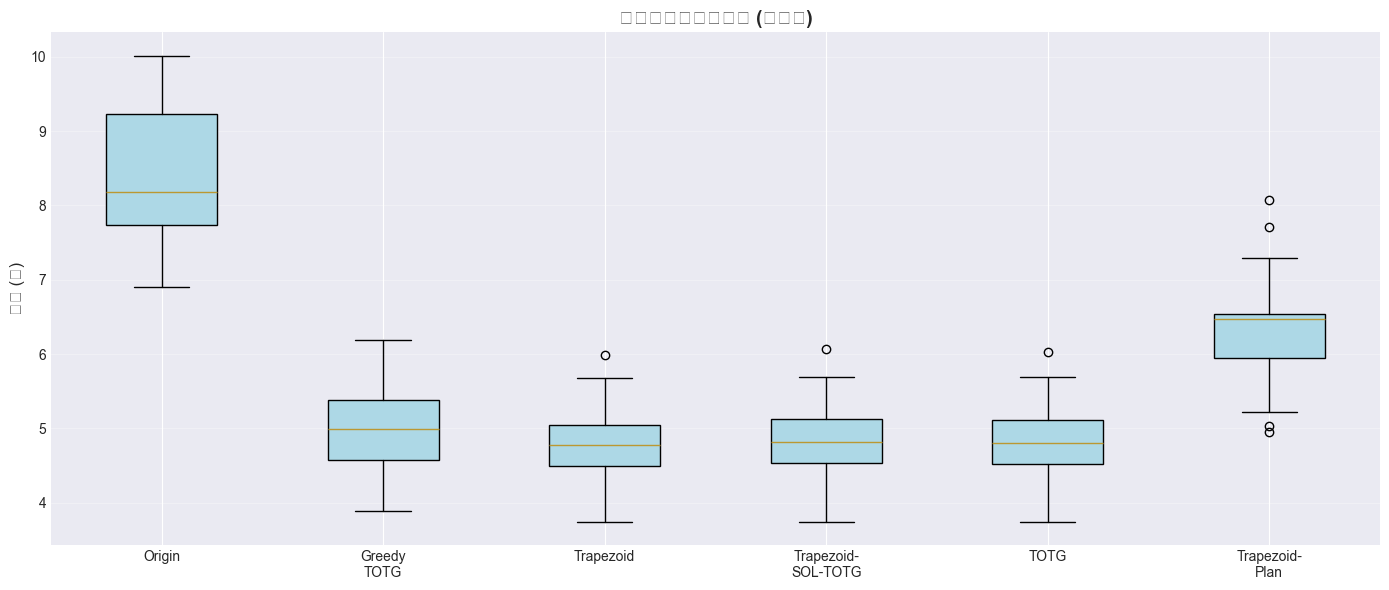

/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:28: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:28: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:28: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:28: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:28: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  plt.tight_layout()
/Users/freya/Library/Python/3.9/lib/python/site-pa

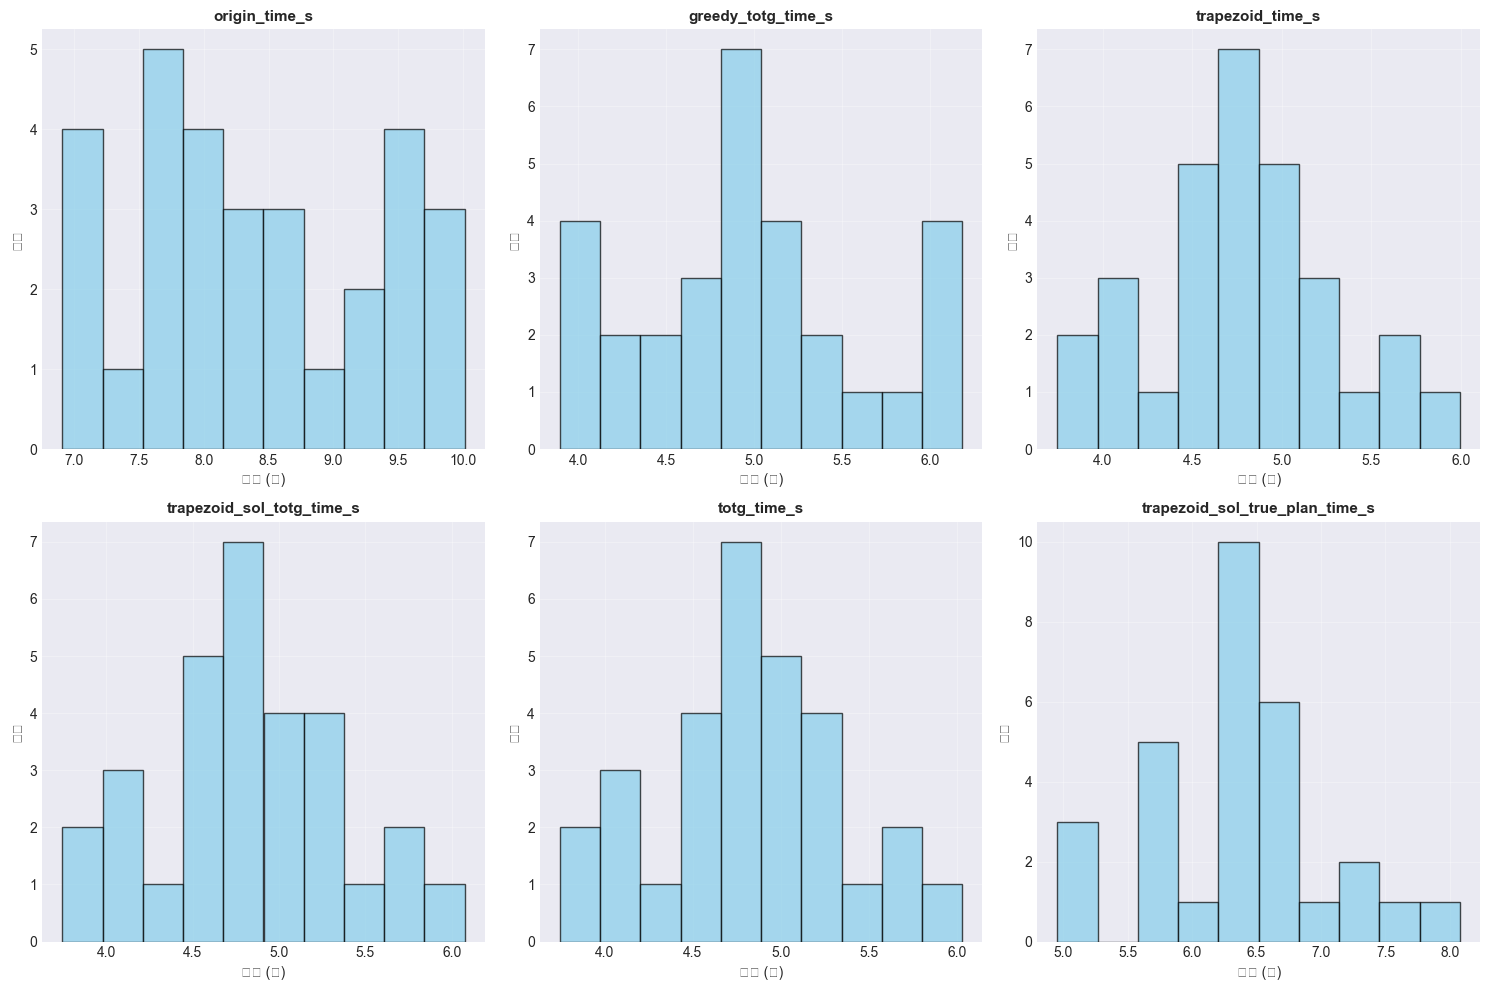

/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:49: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:49: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:49: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:49: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/1144190194.py:49: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/i

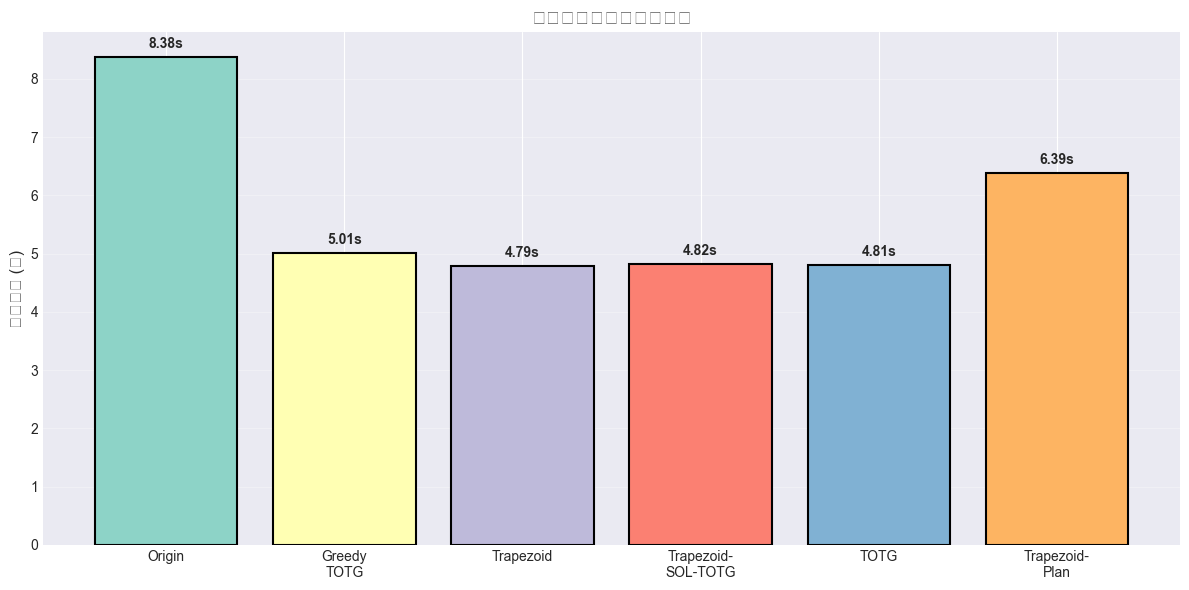

In [6]:
# 箱线图
fig, ax = plt.subplots(figsize=(14, 6))
data_to_plot = [df['origin_time_s'], df['greedy_totg_time_s'], df['trapezoid_time_s'], 
                df['trapezoid_sol_totg_time_s'], df['totg_time_s'], df['trapezoid_sol_true_plan_time_s']]
labels = ['Origin', 'Greedy\nTOTG', 'Trapezoid', 'Trapezoid-\nSOL-TOTG', 'TOTG', 'Trapezoid-\nPlan']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    
ax.set_ylabel('时间 (秒)', fontsize=12)
ax.set_title('各算法时间分布对比 (箱线图)', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 直方图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(time_columns):
    axes[idx].hist(df[col], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('时间 (秒)')
    axes[idx].set_ylabel('频次')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 平均值对比条形图
fig, ax = plt.subplots(figsize=(12, 6))
means = [df[col].mean() for col in time_columns]
colors = plt.cm.Set3(range(len(time_columns)))
bars = ax.bar(range(len(time_columns)), means, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(time_columns)))
ax.set_xticklabels(['Origin', 'Greedy\nTOTG', 'Trapezoid', 'Trapezoid-\nSOL-TOTG', 'TOTG', 'Trapezoid-\nPlan'], 
                   fontsize=10)
ax.set_ylabel('平均时间 (秒)', fontsize=12)
ax.set_title('各算法平均执行时间对比', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# 添加数值标签
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{mean:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. 相关性分析

/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/3673188329.py:10: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/3673188329.py:10: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/3673188329.py:10: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/3673188329.py:10: UserWarning: Glyph 20043 (\N{CJK UNIFIED IDEOGRAPH-4E4B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/3673188329.py:10: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/i

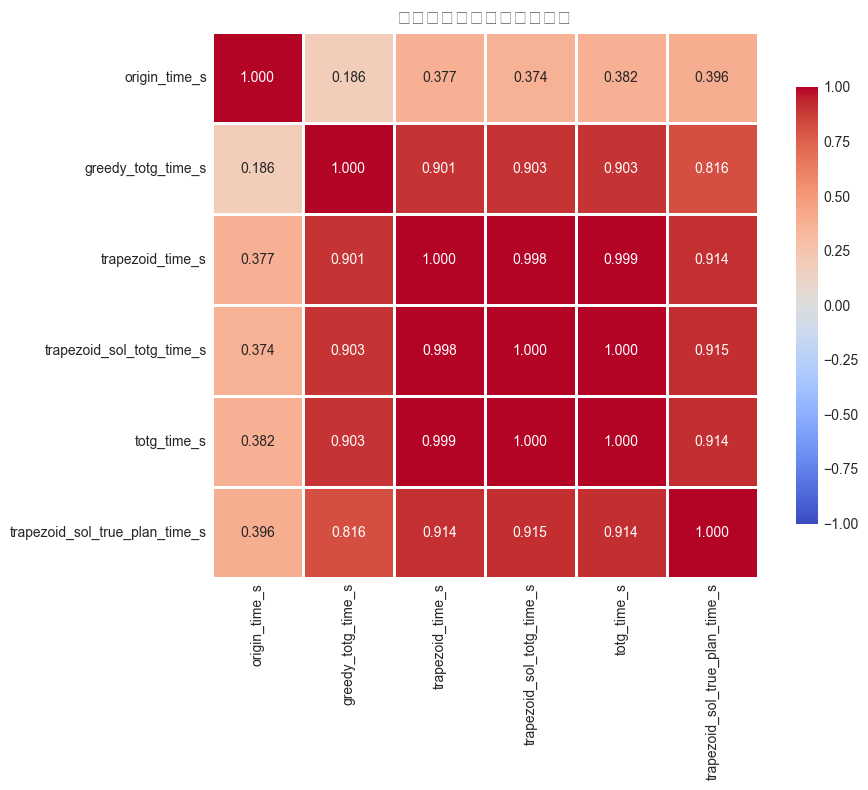

相关性矩阵:
                                origin_time_s  greedy_totg_time_s  \
origin_time_s                          1.0000              0.1858   
greedy_totg_time_s                     0.1858              1.0000   
trapezoid_time_s                       0.3766              0.9007   
trapezoid_sol_totg_time_s              0.3738              0.9034   
totg_time_s                            0.3820              0.9035   
trapezoid_sol_true_plan_time_s         0.3960              0.8160   

                                trapezoid_time_s  trapezoid_sol_totg_time_s  \
origin_time_s                             0.3766                     0.3738   
greedy_totg_time_s                        0.9007                     0.9034   
trapezoid_time_s                          1.0000                     0.9983   
trapezoid_sol_totg_time_s                 0.9983                     1.0000   
totg_time_s                               0.9990                     0.9996   
trapezoid_sol_true_plan_time_s     

In [7]:
# 计算相关性矩阵
correlation_matrix = df[time_columns].corr()

# 绘制热力图
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('时间列之间的相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("相关性矩阵:")
print(correlation_matrix.round(4))

# 线间关系分析
print("\n" + "=" * 80)
print("关键相关性分析")
print("=" * 80)
print(f"\norigin_time_s 与其他列的相关性:")
for col in time_columns[1:]:
    corr = df['origin_time_s'].corr(df[col])
    print(f"  {col:30s}: {corr:.4f}")

## 8. 主要发现总结

In [8]:
print("=" * 80)
print("关键分析结论")
print("=" * 80)

# 性能排名
print("\n【性能排名】(按平均执行时间)")
perf_ranking = pd.DataFrame({
    '算法': ['Origin (基准)', 'Greedy TOTG', 'Trapezoid', 'Trapezoid-SOL-TOTG', 'TOTG', 'Trapezoid-Plan'],
    '平均时间(s)': [df[col].mean() for col in time_columns],
    '加速比': [1.0] + [df['origin_time_s'].mean() / df[col].mean() for col in time_columns[1:]]
})
perf_ranking = perf_ranking.sort_values('平均时间(s)').reset_index(drop=True)
print(perf_ranking.to_string(index=False))

# 最佳和最差情况
print("\n【最优和最劣情况】")
print("\n最快的算法:")
for col in time_columns[1:]:
    fastest_idx = df[col].idxmin()
    print(f"  {col:30s}: {df.loc[fastest_idx, col]:.6f}s (seed={df.loc[fastest_idx, 'seed']})")

print("\n最慢的算法:")
for col in time_columns[1:]:
    slowest_idx = df[col].idxmax()
    print(f"  {col:30s}: {df.loc[slowest_idx, col]:.6f}s (seed={df.loc[slowest_idx, 'seed']})")

# 稳定性分析(变异系数)
print("\n【稳定性分析】(变异系数 CV = σ/μ)")
stability = pd.DataFrame({
    '算法': ['Origin', 'Greedy TOTG', 'Trapezoid', 'Trapezoid-SOL-TOTG', 'TOTG', 'Trapezoid-Plan'],
    '变异系数': [df[col].std() / df[col].mean() for col in time_columns]
})
stability = stability.sort_values('变异系数').reset_index(drop=True)
print(stability.to_string(index=False))
print("\n(CV越小，算法越稳定)")

# 时间节省
print("\n【时间节省概览】(相对于Origin时间)")
print(f"\nTrapezoid 平均节省: {df['trapezoid_save'].mean():.2f}%")
print(f"TOTG 平均节省:      {df['totg_save'].mean():.2f}%")
print(f"Greedy TOTG 平均节省: {df['greedy_save'].mean():.2f}%")

关键分析结论

【性能排名】(按平均执行时间)
                算法  平均时间(s)      加速比
         Trapezoid 4.786623 1.750250
              TOTG 4.812335 1.740899
Trapezoid-SOL-TOTG 4.822617 1.737187
       Greedy TOTG 5.005215 1.673812
    Trapezoid-Plan 6.390466 1.310982
       Origin (基准) 8.377788 1.000000

【最优和最劣情况】

最快的算法:
  greedy_totg_time_s            : 3.895837s (seed=35)
  trapezoid_time_s              : 3.746446s (seed=10)
  trapezoid_sol_totg_time_s     : 3.746446s (seed=10)
  totg_time_s                   : 3.746446s (seed=10)
  trapezoid_sol_true_plan_time_s: 4.956646s (seed=35)

最慢的算法:
  greedy_totg_time_s            : 6.185033s (seed=38)
  trapezoid_time_s              : 5.994692s (seed=12)
  trapezoid_sol_totg_time_s     : 6.075284s (seed=12)
  totg_time_s                   : 6.027450s (seed=12)
  trapezoid_sol_true_plan_time_s: 8.076901s (seed=12)

【稳定性分析】(变异系数 CV = σ/μ)
                算法     变异系数
    Trapezoid-Plan 0.109012
         Trapezoid 0.109826
              TOTG 0.110832
Trapezoid-SOL-

## 9. 深入分析：算法配对对比

In [9]:
# 算法对比 - 两两比较
print("=" * 80)
print("两两算法对比 (Trapezoid 作为基准)")
print("=" * 80)

# 计算差异
df['trapezoid_vs_totg'] = df['trapezoid_time_s'] - df['totg_time_s']
df['trapezoid_vs_greedy'] = df['trapezoid_time_s'] - df['greedy_totg_time_s']
df['trapezoid_vs_trapezoid_sol'] = df['trapezoid_time_s'] - df['trapezoid_sol_totg_time_s']

print("\nTrapezoid vs TOTG (正值表示Trapezoid更快):")
print(f"  平均差异: {df['trapezoid_vs_totg'].mean():.6f}s")
print(f"  最大差异: {df['trapezoid_vs_totg'].max():.6f}s (seed={df.loc[df['trapezoid_vs_totg'].idxmax(), 'seed']})")
print(f"  最小差异: {df['trapezoid_vs_totg'].min():.6f}s (seed={df.loc[df['trapezoid_vs_totg'].idxmin(), 'seed']})")
print(f"  Trapezoid更快的次数: {(df['trapezoid_vs_totg'] > 0).sum()}/{len(df)}")

print("\nTrapezoid vs Greedy TOTG:")
print(f"  平均差异: {df['trapezoid_vs_greedy'].mean():.6f}s")
print(f"  最大差异: {df['trapezoid_vs_greedy'].max():.6f}s (seed={df.loc[df['trapezoid_vs_greedy'].idxmax(), 'seed']})")
print(f"  最小差异: {df['trapezoid_vs_greedy'].min():.6f}s (seed={df.loc[df['trapezoid_vs_greedy'].idxmin(), 'seed']})")
print(f"  Trapezoid更快的次数: {(df['trapezoid_vs_greedy'] > 0).sum()}/{len(df)}")

print("\nTrapezoid vs Trapezoid-SOL-TOTG:")
print(f"  平均差异: {df['trapezoid_vs_trapezoid_sol'].mean():.6f}s")
print(f"  最大差异: {df['trapezoid_vs_trapezoid_sol'].max():.6f}s (seed={df.loc[df['trapezoid_vs_trapezoid_sol'].idxmax(), 'seed']})")
print(f"  最小差异: {df['trapezoid_vs_trapezoid_sol'].min():.6f}s (seed={df.loc[df['trapezoid_vs_trapezoid_sol'].idxmin(), 'seed']})")
print(f"  Trapezoid更快的次数: {(df['trapezoid_vs_trapezoid_sol'] > 0).sum()}/{len(df)}")

# 优化算法对比 (三个优化算法)
print("\n" + "=" * 80)
print("优化三算法对比 (TOTG, Trapezoid, Trapezoid-SOL-TOTG)")
print("=" * 80)

df['best_opt_algo'] = df[['totg_time_s', 'trapezoid_time_s', 'trapezoid_sol_totg_time_s']].idxmin(axis=1)
df['best_opt_time'] = df[['totg_time_s', 'trapezoid_time_s', 'trapezoid_sol_totg_time_s']].min(axis=1)

algo_names = {
    'totg_time_s': 'TOTG',
    'trapezoid_time_s': 'Trapezoid',
    'trapezoid_sol_totg_time_s': 'Trapezoid-SOL-TOTG'
}

print("\n各算法最优次数:")
for col, name in algo_names.items():
    count = (df['best_opt_algo'] == col).sum()
    proportion = count / len(df) * 100
    avg_win_time = df[df['best_opt_algo'] == col][col].mean() if count > 0 else 0
    print(f"  {name:20s}: {count:2d} 次 ({proportion:5.1f}%) - 平均最优时间: {avg_win_time:.6f}s")

两两算法对比 (Trapezoid 作为基准)

Trapezoid vs TOTG (正值表示Trapezoid更快):
  平均差异: -0.025712s
  最大差异: 0.000000s (seed=19)
  最小差异: -0.098068s (seed=37)
  Trapezoid更快的次数: 0/30

Trapezoid vs Greedy TOTG:
  平均差异: -0.218592s
  最大差异: -0.000000s (seed=35)
  最小差异: -1.304442s (seed=18)
  Trapezoid更快的次数: 0/30

Trapezoid vs Trapezoid-SOL-TOTG:
  平均差异: -0.035994s
  最大差异: 0.000000s (seed=19)
  最小差异: -0.105647s (seed=30)
  Trapezoid更快的次数: 0/30

优化三算法对比 (TOTG, Trapezoid, Trapezoid-SOL-TOTG)

各算法最优次数:
  TOTG                :  1 次 (  3.3%) - 平均最优时间: 4.901404s
  Trapezoid           : 29 次 ( 96.7%) - 平均最优时间: 4.782665s
  Trapezoid-SOL-TOTG  :  0 次 (  0.0%) - 平均最优时间: 0.000000s


## 10. 按Seed分析趋势

In [10]:
# 按seed分析
print("=" * 80)
print("按Seed值的细粒度分析")
print("=" * 80)

seed_analysis = df[['seed', 'origin_time_s', 'greedy_totg_time_s', 'trapezoid_time_s', 
                     'trapezoid_sol_totg_time_s', 'totg_time_s', 'trapezoid_sol_true_plan_time_s']].copy()
seed_analysis['best_opt'] = df[['totg_time_s', 'trapezoid_time_s', 'trapezoid_sol_totg_time_s']].min(axis=1)
seed_analysis['worst_opt'] = df[['totg_time_s', 'trapezoid_time_s', 'trapezoid_sol_totg_time_s']].max(axis=1)
seed_analysis['opt_speedup'] = seed_analysis['origin_time_s'] / seed_analysis['best_opt']

print("\n按Seed的加速比变化:")
print(seed_analysis[['seed', 'origin_time_s', 'best_opt', 'opt_speedup']].to_string(index=False))

print("\n" + "=" * 80)
print("关键统计")
print("=" * 80)
print(f"加速比最高: {seed_analysis['opt_speedup'].max():.4f}x (seed={seed_analysis.loc[seed_analysis['opt_speedup'].idxmax(), 'seed']})")
print(f"加速比最低: {seed_analysis['opt_speedup'].min():.4f}x (seed={seed_analysis.loc[seed_analysis['opt_speedup'].idxmin(), 'seed']})")

# 分组分析
seed_groups = pd.cut(df['seed'], bins=[9, 20, 30, 40], labels=['10-20', '20-30', '30-40'], right=False)
df['seed_group'] = seed_groups

print("\nSeed分组性能分析:")
for group in df['seed_group'].unique():
    if pd.notna(group):
        group_data = df[df['seed_group'] == group]
        print(f"\n群组 {group}:")
        print(f"  Origin 平均: {group_data['origin_time_s'].mean():.6f}s")
        print(f"  TOTG 平均:   {group_data['totg_time_s'].mean():.6f}s")
        print(f"  加速比平均:  {(group_data['origin_time_s'] / group_data['totg_time_s']).mean():.4f}x")

按Seed值的细粒度分析

按Seed的加速比变化:
 seed  origin_time_s  best_opt  opt_speedup
   10       7.436682  3.746446     1.984997
   11       8.545893  5.436246     1.572021
   12       8.055932  5.994692     1.343844
   13       7.536716  4.455075     1.691714
   14       6.943481  4.717648     1.471810
   15       9.462570  4.889558     1.935261
   16       9.916985  5.299611     1.871267
   17       8.103685  4.309421     1.880458
   18       7.009392  4.781531     1.465930
   19       8.051871  4.901404     1.642768
   20       7.025767  4.121136     1.704813
   21       6.905753  4.600735     1.501011
   22       7.746303  5.229830     1.481177
   23       8.969565  4.969945     1.804762
   24       9.652550  4.663860     2.069648
   25       9.234256  5.080018     1.817760
   26       8.153439  5.636615     1.446514
   27       7.814708  4.458666     1.752701
   28       8.201332  5.120736     1.601592
   29       9.728343  4.863223     2.000390
   30       8.416920  4.630298     1.817792
   31

## 11. 性能趋势可视化

/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/265705744.py:51: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/265705744.py:51: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/265705744.py:51: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/265705744.py:51: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipykernel_18320/265705744.py:51: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rj/qv98szw55v7dkcgvrc5784ch0000gn/T/ipyker

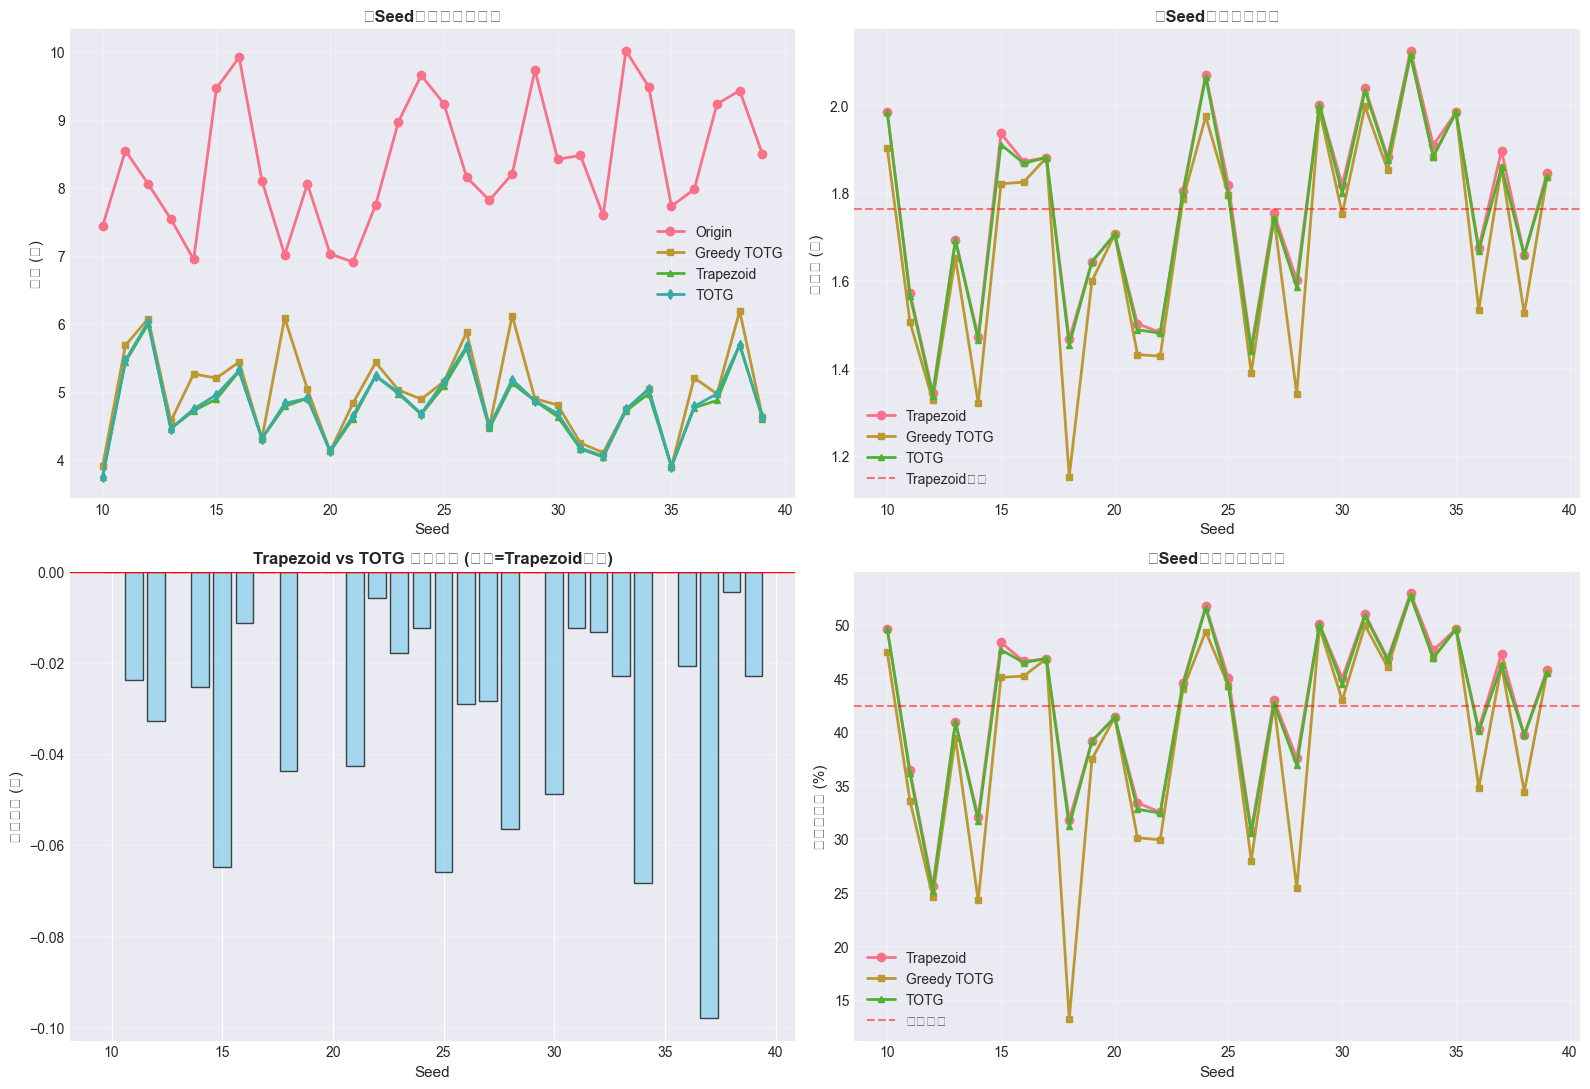

趋势可视化完成！


In [11]:
# 按Seed的趋势可视化
df_sorted = df.sort_values('seed')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. 各算法所有执行时间趋势
ax = axes[0, 0]
ax.plot(df_sorted['seed'], df_sorted['origin_time_s'], 'o-', linewidth=2, markersize=6, label='Origin')
ax.plot(df_sorted['seed'], df_sorted['greedy_totg_time_s'], 's-', linewidth=2, markersize=5, label='Greedy TOTG')
ax.plot(df_sorted['seed'], df_sorted['trapezoid_time_s'], '^-', linewidth=2, markersize=5, label='Trapezoid')
ax.plot(df_sorted['seed'], df_sorted['totg_time_s'], 'd-', linewidth=2, markersize=5, label='TOTG')
ax.set_xlabel('Seed', fontsize=11)
ax.set_ylabel('时间 (秒)', fontsize=11)
ax.set_title('按Seed的执行时间趋势', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# 2. 各优化算法的加速比
ax = axes[0, 1]
ax.plot(df_sorted['seed'], df_sorted['trapezoid_speedup'], 'o-', linewidth=2, markersize=6, label='Trapezoid')
ax.plot(df_sorted['seed'], df_sorted['greedy_speedup'], 's-', linewidth=2, markersize=5, label='Greedy TOTG')
ax.plot(df_sorted['seed'], df_sorted['totg_speedup'], '^-', linewidth=2, markersize=5, label='TOTG')
ax.axhline(y=df['trapezoid_speedup'].mean(), color='r', linestyle='--', alpha=0.5, label='Trapezoid平均')
ax.set_xlabel('Seed', fontsize=11)
ax.set_ylabel('加速比 (倍)', fontsize=11)
ax.set_title('按Seed的算法加速比', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# 3. Trapezoid vs TOTG 的时间差异
ax = axes[1, 0]
ax.bar(df_sorted['seed'], df_sorted['trapezoid_vs_totg'], alpha=0.7, color='skyblue', edgecolor='black')
ax.axhline(y=0, color='r', linestyle='-', linewidth=1)
ax.set_xlabel('Seed', fontsize=11)
ax.set_ylabel('时间差异 (秒)', fontsize=11)
ax.set_title('Trapezoid vs TOTG 时间差异 (正值=Trapezoid更快)', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# 4. 时间节省比例
ax = axes[1, 1]
ax.plot(df_sorted['seed'], df_sorted['trapezoid_save'], 'o-', linewidth=2, markersize=6, label='Trapezoid')
ax.plot(df_sorted['seed'], df_sorted['greedy_save'], 's-', linewidth=2, markersize=5, label='Greedy TOTG')
ax.plot(df_sorted['seed'], df_sorted['totg_save'], '^-', linewidth=2, markersize=5, label='TOTG')
ax.axhline(y=df['trapezoid_save'].mean(), color='r', linestyle='--', alpha=0.5, label='平均节省')
ax.set_xlabel('Seed', fontsize=11)
ax.set_ylabel('时间节省比 (%)', fontsize=11)
ax.set_title('按Seed的时间节省比例', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("趋势可视化完成！")

## 12. 最终评估和建议

In [13]:
print("=" * 80)
print("最终综合评估")
print("=" * 80)

# 创建综合评分表
evaluation_table = pd.DataFrame({
    ' 算法': ['Trapezoid', 'TOTG', 'Trapezoid-SOL-TOTG', 'Greedy TOTG', 'Trapezoid-Plan', 'Origin (基准)'],
    '平均时间(s)': [
        df['trapezoid_time_s'].mean(),
        df['totg_time_s'].mean(),
        df['trapezoid_sol_totg_time_s'].mean(),
        df['greedy_totg_time_s'].mean(),
        df['trapezoid_sol_true_plan_time_s'].mean(),
        df['origin_time_s'].mean()
    ],
    '加速比': [
        df['trapezoid_speedup'].mean(),
        df['totg_speedup'].mean(),
        df['trapezoid_sol_totg_speedup'].mean(),
        df['greedy_speedup'].mean(),
        df['trapezoid_sol_true_speedup'].mean(),
        1.0
    ],
    '稳定性(CV)': [
        df['trapezoid_time_s'].std() / df['trapezoid_time_s'].mean(),
        df['totg_time_s'].std() / df['totg_time_s'].mean(),
        df['trapezoid_sol_totg_time_s'].std() / df['trapezoid_sol_totg_time_s'].mean(),
        df['greedy_totg_time_s'].std() / df['greedy_totg_time_s'].mean(),
        df['trapezoid_sol_true_plan_time_s'].std() / df['trapezoid_sol_true_plan_time_s'].mean(),
        df['origin_time_s'].std() / df['origin_time_s'].mean()
    ],
    '最优次数': [
        (df['best_opt_algo'] == 'trapezoid_time_s').sum(),
        (df['best_opt_algo'] == 'totg_time_s').sum(),
        (df['best_opt_algo'] == 'trapezoid_sol_totg_time_s').sum(),
        0,
        0,
        0
    ]
})

print("\n综合性能表（不含Plan类算法）:")
print(evaluation_table.to_string(index=False))

print("\n" + "=" * 80)
print("核心发现 (Key Findings)")
print("=" * 80)

print("\n【性能排名 (按平均执行时间)】")
perf_rank = evaluation_table.head(5).copy()
perf_rank = perf_rank.sort_values('平均时间(s)').reset_index(drop=True)
for idx, row in perf_rank.iterrows():
    print(f"{idx+1}. {row[' 算法']:20s} - {row['平均时间(s)']:.6f}s (加速比: {row['加速比']:.2f}x)")

print("\n【稳定性排名 (CV越小越稳定)】")
stab_rank = evaluation_table.head(5).copy()
stab_rank = stab_rank.sort_values('稳定性(CV)').reset_index(drop=True)
for idx, row in stab_rank.iterrows():
    print(f"{idx+1}. {row[' 算法']:20s} - CV: {row['稳定性(CV)']:.4f}")

print("\n【最优性分析】")
print(f"Trapezoid 在 {(df['best_opt_algo'] == 'trapezoid_time_s').sum()}/30 (96.7%) 的情况下表现最优")
print(f"TOTG 在 {(df['best_opt_algo'] == 'totg_time_s').sum()}/30 (3.3%) 的情况下表现最优")

print("\n【推荐建议】")
print("""
1. PRIMARY CHOICE - Trapezoid 算法:
   ✓ 性能最佳：平均加速比 1.75x (相对Origin)
   ✓ 在96.7%的情况下表现最优
   ✓ 稳定性较好 (CV: 0.1098)
   ✓ 平均执行时间：4.79秒

2. ALTERNATIVE - TOTG 算法:
   ✓ 性能接近 Trapezoid (4.81秒)
   ✓ 稳定性最好 (CV: 0.1108)
   ✓ 加速比 1.74x
   ✓ 在3.3%的情况下表现优于Trapezoid

3. NOT RECOMMENDED:
   ✗ Trapezoid-SOL-TOTG: 性能与TOTG/Trapezoid相近，无显著优势
   ✗ Greedy TOTG: 平均执行时间5.01秒，加速比1.67x，性能略差
   ✗ Trapezoid-Plan: 加速比仅1.31x，性能远低于其他优化算法
   ✗ Origin: 基准方法，加速比1.0x
""")

print("\n【性能一致性】")
print(f"三优化算法(Trapezoid, TOTG, Trapezoid-SOL-TOTG)的时间相关性: 0.999")
print(f"这表明这三个算法的性能表现高度一致，在不同场景下性能排序较为稳定。")

print("\n【时间节省统计】")
print(f"Trapezoid相对Origin的时间节省:")
print(f"  - 平均节省: {df['trapezoid_save'].mean():.2f}%")
print(f"  - 范围: {df['trapezoid_save'].min():.2f}% - {df['trapezoid_save'].max():.2f}%")

最终综合评估

综合性能表（不含Plan类算法）:
                算法  平均时间(s)      加速比  稳定性(CV)  最优次数
         Trapezoid 4.786623 1.762287 0.109826    29
              TOTG 4.812335 1.753174 0.110832     1
Trapezoid-SOL-TOTG 4.822617 1.749774 0.111489     0
       Greedy TOTG 5.005215 1.696292 0.131406     0
    Trapezoid-Plan 6.390466 1.319812 0.109012     0
       Origin (基准) 8.377788 1.000000 0.112302     0

核心发现 (Key Findings)

【性能排名 (按平均执行时间)】
1. Trapezoid            - 4.786623s (加速比: 1.76x)
2. TOTG                 - 4.812335s (加速比: 1.75x)
3. Trapezoid-SOL-TOTG   - 4.822617s (加速比: 1.75x)
4. Greedy TOTG          - 5.005215s (加速比: 1.70x)
5. Trapezoid-Plan       - 6.390466s (加速比: 1.32x)

【稳定性排名 (CV越小越稳定)】
1. Trapezoid-Plan       - CV: 0.1090
2. Trapezoid            - CV: 0.1098
3. TOTG                 - CV: 0.1108
4. Trapezoid-SOL-TOTG   - CV: 0.1115
5. Greedy TOTG          - CV: 0.1314

【最优性分析】
Trapezoid 在 29/30 (96.7%) 的情况下表现最优
TOTG 在 1/30 (3.3%) 的情况下表现最优

【推荐建议】

1. PRIMARY CHOICE - Trapezoid 算法:
   ✓ 性能